# Member 2 Modeling Notebook: NYC Street Tree Health Predictor

**Role:** Member 2 — Modeling and Evaluation Lead
**Project:** NYC Street Tree Health Predictor
**Goal:** Train a baseline and an improved classifier to predict tree `health`
(Good / Fair / Poor), tune the improved model on macro-F1, and evaluate honestly
given class imbalance.

This notebook uses the model-ready dataset handed off by Member 1
(`data/nyc_tree_member1_model_ready_sample.csv`). The full, saved artifacts are
produced by `scripts/create_member2_package.py`; this notebook tells the same
story interactively.

## 1. Imports and data loading

In [1]:
%matplotlib inline
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

RANDOM_STATE = 42
df = pd.read_csv(Path("data/nyc_tree_member1_model_ready_sample.csv"))
print("Dataset shape:", df.shape)
df[["health", "tree_dbh", "species_top15_or_other", "boroname"]].head()

Dataset shape: (49994, 23)


,health,tree_dbh,species_top15_or_other,boroname
0,Fair,3,red maple,Queens
1,Fair,21,pin oak,Queens
2,Good,3,honeylocust,Brooklyn
3,Good,10,honeylocust,Brooklyn
4,Good,21,American linden,Brooklyn


## 2. Features and target

We follow the feature contract agreed with Member 1 (see `member1_handoff.md`).
The target `health` is imbalanced, which is why we will report **macro-F1** and a
**confusion matrix**, not accuracy alone.

In [2]:
TARGET = "health"
NUMERIC = ["tree_dbh", "problem_count"]
CATEGORICAL = ["species_top15_or_other", "steward", "guards", "sidewalk",
               "has_problem", "boroname", "dbh_group", "curb_loc"]
CLASS_ORDER = ["Good", "Fair", "Poor"]

X = df[NUMERIC + CATEGORICAL].copy()
y = df[TARGET].copy()
print("Class distribution:")
print(y.value_counts())
print("\nClass share:")
print((y.value_counts(normalize=True) * 100).round(2))

Class distribution:
health
Good    37779
Fair     9403
Poor     2812
Name: count, dtype: int64

Class share:
health
Good    75.57
Fair    18.81
Poor     5.62
Name: proportion, dtype: float64


## 3. Train/test split and preprocessing pipeline

We use a stratified 80/20 split and a `ColumnTransformer` that scales the numeric
features (helps Logistic Regression) and one-hot encodes the categoricals.
`handle_unknown="ignore"` keeps the deployed app from breaking on unseen values.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)

preprocess = ColumnTransformer([
    ("num", StandardScaler(), NUMERIC),
    ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL),
])
print("Train rows:", len(X_train), " Test rows:", len(X_test))

Train rows: 39995  Test rows: 9999


## 4. Baseline model — Logistic Regression

`class_weight="balanced"` makes the baseline pay attention to the rare classes
instead of always predicting Good.

In [4]:
logreg = Pipeline([
    ("prep", preprocess),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced",
                               random_state=RANDOM_STATE)),
])
logreg.fit(X_train, y_train)
lr_pred = logreg.predict(X_test)
print("Accuracy :", round(accuracy_score(y_test, lr_pred), 4))
print("Macro-F1 :", round(f1_score(y_test, lr_pred, average="macro"), 4))
print(classification_report(y_test, lr_pred, labels=CLASS_ORDER, zero_division=0))

Accuracy : 0.4936
Macro-F1 : 0.3572
              precision    recall  f1-score   support

        Good       0.83      0.55      0.66      7556
        Fair       0.23      0.22      0.23      1881
        Poor       0.11      0.59      0.18       562

    accuracy                           0.49      9999
   macro avg       0.39      0.46      0.36      9999
weighted avg       0.67      0.49      0.55      9999



## 5. Improved model — Random Forest with tuning

We tune Random Forest depth and leaf size with `GridSearchCV` scored on macro-F1
(3-fold). The search runs on a stratified subsample for speed; the winning
configuration is then refit on the full training set. `class_weight=
"balanced_subsample"` handles the imbalance.

In [5]:
rf_pipe = Pipeline([
    ("prep", preprocess),
    ("clf", RandomForestClassifier(class_weight="balanced_subsample",
                                   random_state=RANDOM_STATE, n_jobs=1)),
])
param_grid = {
    "clf__max_depth": [10, 16],
    "clf__min_samples_leaf": [2, 5],
    "clf__n_estimators": [150],
    "clf__max_features": ["sqrt"],
}
X_sub, _, y_sub, _ = train_test_split(
    X_train, y_train, train_size=8000, random_state=RANDOM_STATE, stratify=y_train)
search = GridSearchCV(rf_pipe, param_grid, scoring="f1_macro",
                      cv=StratifiedKFold(3, shuffle=True, random_state=RANDOM_STATE),
                      n_jobs=1, refit=False)
search.fit(X_sub, y_sub)
print("Best CV macro-F1 (subsample):", round(search.best_score_, 4))
print("Best params:", search.best_params_)

best = {k.replace("clf__", ""): v for k, v in search.best_params_.items()}
rf = Pipeline([
    ("prep", preprocess),
    ("clf", RandomForestClassifier(class_weight="balanced_subsample",
                                   random_state=RANDOM_STATE, n_jobs=1, **best)),
])
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print("\nRandom Forest test accuracy:", round(accuracy_score(y_test, rf_pred), 4))
print("Random Forest test macro-F1:", round(f1_score(y_test, rf_pred, average="macro"), 4))

Best CV macro-F1 (subsample): 0.4026
Best params: {'clf__max_depth': 16, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 2, 'clf__n_estimators': 150}



Random Forest test accuracy: 0.5818
Random Forest test macro-F1: 0.4098


## 6. Evaluation — confusion matrix and per-class performance

              precision    recall  f1-score   support

        Good       0.83      0.66      0.74      7556
        Fair       0.28      0.30      0.29      1881
        Poor       0.13      0.45      0.20       562

    accuracy                           0.58      9999
   macro avg       0.41      0.47      0.41      9999
weighted avg       0.69      0.58      0.62      9999



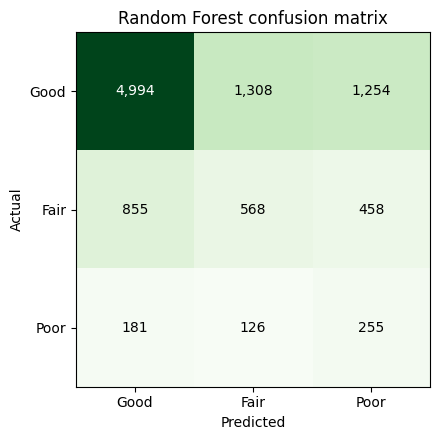

In [6]:
print(classification_report(y_test, rf_pred, labels=CLASS_ORDER, zero_division=0))

cm = confusion_matrix(y_test, rf_pred, labels=CLASS_ORDER)
fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(cm, cmap="Greens")
ax.set_xticks(range(3)); ax.set_xticklabels(CLASS_ORDER)
ax.set_yticks(range(3)); ax.set_yticklabels(CLASS_ORDER)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Random Forest confusion matrix")
for i in range(3):
    for j in range(3):
        ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.tight_layout(); plt.show()

**Reading the matrix:** the model identifies **Good** trees well but confuses
**Fair** and **Poor**. That is expected for a rare-class problem and is exactly why
macro-F1 is the headline metric.

## 7. Feature importance

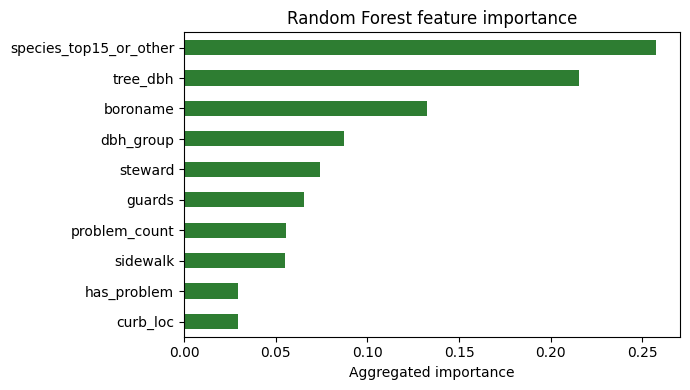

species_top15_or_other    0.257578
tree_dbh                  0.215107
boroname                  0.132489
dbh_group                 0.086974
steward                   0.074149
guards                    0.065132
problem_count             0.055424
sidewalk                  0.054767
has_problem               0.029250
curb_loc                  0.029130
dtype: float64

In [7]:
feat_names = rf.named_steps["prep"].get_feature_names_out()
importances = rf.named_steps["clf"].feature_importances_
agg = {}
for fname, imp in zip(feat_names, importances):
    raw = fname.split("__", 1)[1]
    base = next((c for c in NUMERIC + CATEGORICAL if raw == c or raw.startswith(c + "_")), raw)
    agg[base] = agg.get(base, 0.0) + float(imp)
fi = pd.Series(agg).sort_values()

ax = fi.plot(kind="barh", figsize=(7, 4), color="#2E7D32",
             title="Random Forest feature importance")
ax.set_xlabel("Aggregated importance")
plt.tight_layout(); plt.show()
fi.sort_values(ascending=False)

## 8. Model comparison

In [8]:
comparison = pd.DataFrame([
    {"model": "Logistic Regression (baseline)",
     "accuracy": accuracy_score(y_test, lr_pred),
     "macro_f1": f1_score(y_test, lr_pred, average="macro")},
    {"model": "Random Forest (tuned)",
     "accuracy": accuracy_score(y_test, rf_pred),
     "macro_f1": f1_score(y_test, rf_pred, average="macro")},
]).round(4)
comparison

,model,accuracy,macro_f1
0,Logistic Regression (baseline),0.4936,0.3572
1,Random Forest (tuned),0.5818,0.4098


**Result:** the tuned Random Forest beats the baseline on both accuracy and
macro-F1, so it is selected as the deployed model. The saved artifacts
(`models/random_forest.joblib`, `models/logistic_regression.joblib`,
`models/model_metadata.json`) are written by `scripts/create_member2_package.py`
and loaded directly by the Streamlit pages.

## 9. Limitations and handoff to Member 3

- **Imbalance:** accuracy alone is misleading; we report macro-F1 + confusion matrix.
- **Snapshot data:** 2015 census; not a live tree-health system.
- **Association, not causation:** importances show what the model uses, not causes.
- **Handoff:** copy `models/` and `data/member2_*` into the app root. Pages 3-5
  (Model Prediction, Feature Importance, Hyperparameter Tuning) load these files.